# Sudbury Dike Swarm ca. 1235 Ma paleomagnetic pole

## Geologic context

The Sudbury dikes are northwest-trending alkali olivine diabase dikes that
intrude the Southern Structural Province of the Canadian Shield around Sudbury,
Ontario, and can be traced across the Grenville Front into the Grenville Province
(Palmer, Merz & Hayatsu, 1977). Away from the front, in the Southern Province,
the dikes carry a westerly directed, shallow primary magnetization (the "Sudbury
dike direction"). Within 2-8 km northwest of the Grenville Front the same dikes
are remagnetized to an east-southeast and downward direction (the "Grenville
Front direction") associated with anomalously high apparent K-Ar ages, recording
a ca. 1000 Ma Grenvillian thermal overprint. The primary remanence is shown to be
a primary cooling remanence by baked-contact tests (site 90 against Gowganda
Formation argillites; Sopher, 1963; Schwarz, 1977).

The dikes are dated by U-Pb baddeleyite at 1235 +7/-3 Ma (Dudas et al., 1994),
compatible with the earlier 1238 ± 4 Ma constraint (Krogh et al., 1987; Fahrig
& West, 1986), superseding the paper's ca. 1250 Ma K-Ar estimate.

## Pole

This notebook recreates the primary Sudbury Dike Swarm pole at the site/dyke
level from 52 Sudbury-dike-direction means: the 38 Palmer et al. (1977) sites,
11 representative Larochelle (1967) dyke means, and three Stupavsky & Symons
(1982) sites whose directions and petrography match the Sudbury swarm. Schwarz &
Buchan (1982) supports the contact-test/uplift context but does not provide an
additional independent site-mean table for this pole.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from study-specific MagIC tables in
`../data/1237_Sudbury/`: `Palmer1977_sites.txt`,
`Larochelle1967_sites.txt`, and `Stupavsky1982_sites.txt`. The dikes are
vertical and the directions are in-situ (`dir_tilt_correction == 0`). The
primary pole is calculated here by combining the 38 Palmer et al. (1977)
`Sudbury Dike direction` sites, the 11 Larochelle (1967) dyke means, and the
three Stupavsky & Symons (1982) Sudbury-like sites. The Palmer et al. (1977)
`Grenville Front direction` sites record the younger overprint and are plotted
for context.

In [2]:
palmer_sites_geo, _ = pt.load_magic_sites('../data/1237_Sudbury/Palmer1977_sites.txt')
larochelle_sites_geo, _ = pt.load_magic_sites('../data/1237_Sudbury/Larochelle1967_sites.txt')
stupavsky_sites_geo, _ = pt.load_magic_sites('../data/1237_Sudbury/Stupavsky1982_sites.txt')

palmer_sudbury = palmer_sites_geo[
    palmer_sites_geo['dir_comp_name'] == 'Sudbury Dike direction'
].copy()
palmer_sudbury['study'] = 'Palmer et al. (1977)'

stupavsky_sudbury = stupavsky_sites_geo[
    stupavsky_sites_geo['dir_comp_name'] == 'Sudbury Dike direction'
].copy()
stupavsky_sudbury['study'] = 'Stupavsky & Symons (1982)'

larochelle_sudbury = larochelle_sites_geo[
    larochelle_sites_geo['dir_comp_name'] == 'Sudbury Dike direction'
].copy()
larochelle_sudbury['study'] = 'Larochelle (1967)'

sudbury = pd.concat([palmer_sudbury, larochelle_sudbury, stupavsky_sudbury],
                    ignore_index=True)
grenville = palmer_sites_geo[
    palmer_sites_geo['dir_comp_name'] == 'Grenville Front direction'
].reset_index(drop=True)

print('Palmer et al. (1977) components:')
print(palmer_sites_geo['dir_comp_name'].value_counts())
print('\nLarochelle (1967) components:')
print(larochelle_sites_geo['dir_comp_name'].value_counts())
print('\nStupavsky & Symons (1982) components:')
print(stupavsky_sites_geo['dir_comp_name'].value_counts())

study_lat, study_lon = 46.3, 278.6
print(f'\nCombined primary pole dataset: {len(sudbury)} Sudbury-dike-direction sites')
print('\nContribution counts by study:')
print(sudbury.groupby('study')['dir_n_samples'].agg(['count', 'sum']))
print(f'Context overprint dataset: {len(grenville)} Palmer Grenville-Front-overprint sites')
sudbury[['study', 'site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
         'dir_n_samples', 'vgp_lat', 'vgp_lon']].head(10)

Palmer et al. (1977) components:
dir_comp_name
Sudbury Dike direction       38
Grenville Front direction    26
Name: count, dtype: int64

Larochelle (1967) components:
dir_comp_name
Sudbury Dike direction    11
Name: count, dtype: int64

Stupavsky & Symons (1982) components:
dir_comp_name
Sudbury Dike direction    3
Name: count, dtype: int64

Combined primary pole dataset: 52 Sudbury-dike-direction sites

Contribution counts by study:
                           count  sum
study                                
Larochelle (1967)             11   43
Palmer et al. (1977)          38  148
Stupavsky & Symons (1982)      3   14
Context overprint dataset: 26 Palmer Grenville-Front-overprint sites


,study,site,lat,lon,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,Palmer et al. (1977),1,46.39,277.24,274,-2,499,4.0,4,2.0,185.0
1,Palmer et al. (1977),2,46.36,277.27,271,-15,529,4.0,4,-5.0,183.0
2,Palmer et al. (1977),3,46.40,277.27,274,7,843,3.0,4,5.0,188.0
3,Palmer et al. (1977),5,46.42,277.35,270,-4,76,29.0,2,-1.0,187.0
4,Palmer et al. (1977),6,46.30,277.72,272,7,129,8.0,4,4.0,189.0
5,Palmer et al. (1977),8,46.25,277.73,261,8,3487,2.0,4,-3.0,197.0
6,Palmer et al. (1977),9,46.24,277.60,263,0,1582,2.0,4,-5.0,193.0
7,Palmer et al. (1977),21,46.20,277.51,277,-4,77,11.0,4,3.0,182.0
8,Palmer et al. (1977),22,46.18,277.48,258,-11,924,3.0,4,-12.0,193.0
9,Palmer et al. (1977),28,46.14,277.62,243,16,90,10.0,4,-12.0,214.0


## Mean pole from site VGPs

The Sudbury dike direction is westerly and shallow, so the VGPs form a single
coherent (near-equatorial) cluster; the Fisher mean is taken without polarity
flipping to preserve the published southern-hemisphere pole convention.

Plon: 192.3  Plat: -2.5
Number of directions in mean (n): 52
Angular radius of 95% confidence (A_95): 2.5
Precision parameter (k) estimate: 61.1

Palmer et al. (1977) pole: 168 W / 2.5 S (= -2.5 N, 192 E), A95 2.5, N=38
recompiled site/dyke-level result here: -2.5 N / 192.3 E, A95 2.5, N=52
prior Nordic compilation (combined, GPMDB 2175): -2.5 N / 192.8 E, A95 2.5, N=52


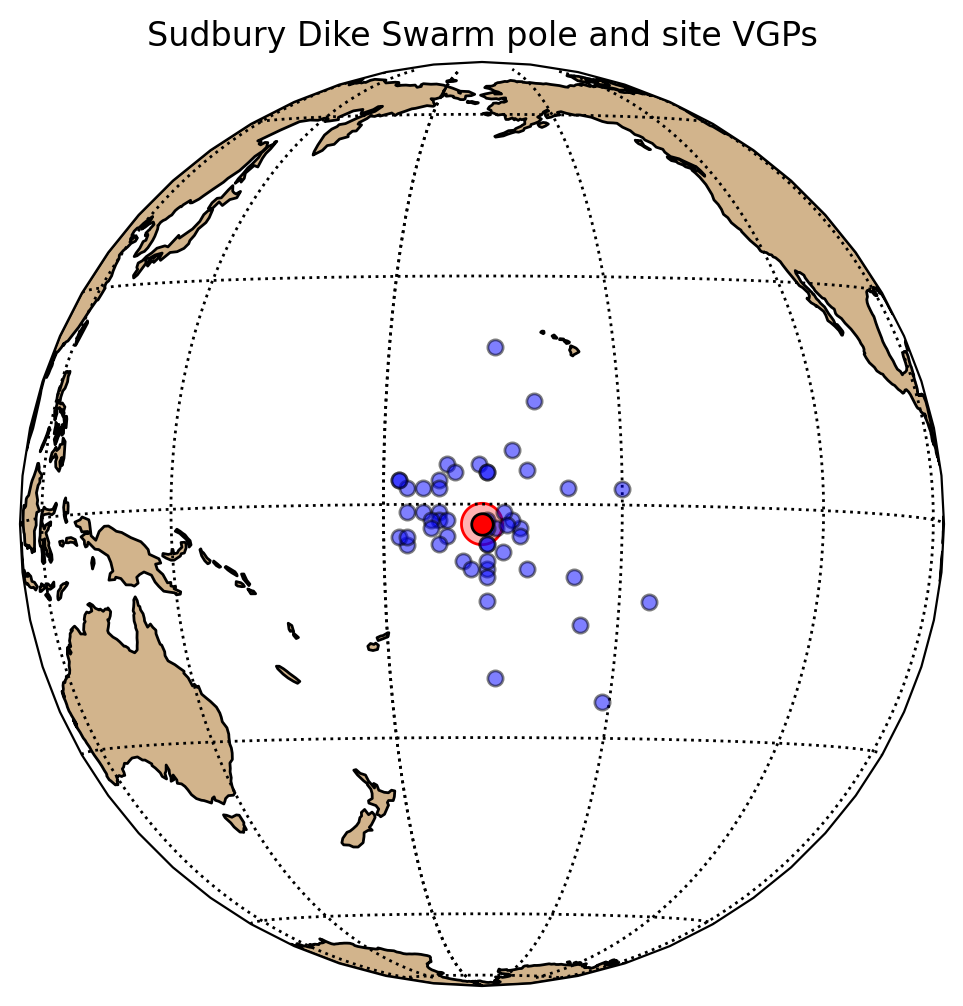

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sudbury, unify_polarity=False)
ipmag.print_pole_mean(pole_mean)
print('\nPalmer et al. (1977) pole: 168 W / 2.5 S (= -2.5 N, 192 E), A95 2.5, N=38')
print(f"recompiled site/dyke-level result here: {pole_mean['inc']:.1f} N / "
      f"{pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}, N={pole_mean['n']}")
print('prior Nordic compilation (combined, GPMDB 2175): -2.5 N / 192.8 E, A95 2.5, N=52')

_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Sudbury Dike Swarm pole and site VGPs')
plt.show()

## Mean direction (in-situ)

Dec: 265.7  Inc: 1.2
Number of directions in mean (n): 52
Angular radius of 95% confidence (a_95): 3.5
Precision parameter (k) estimate: 32.3


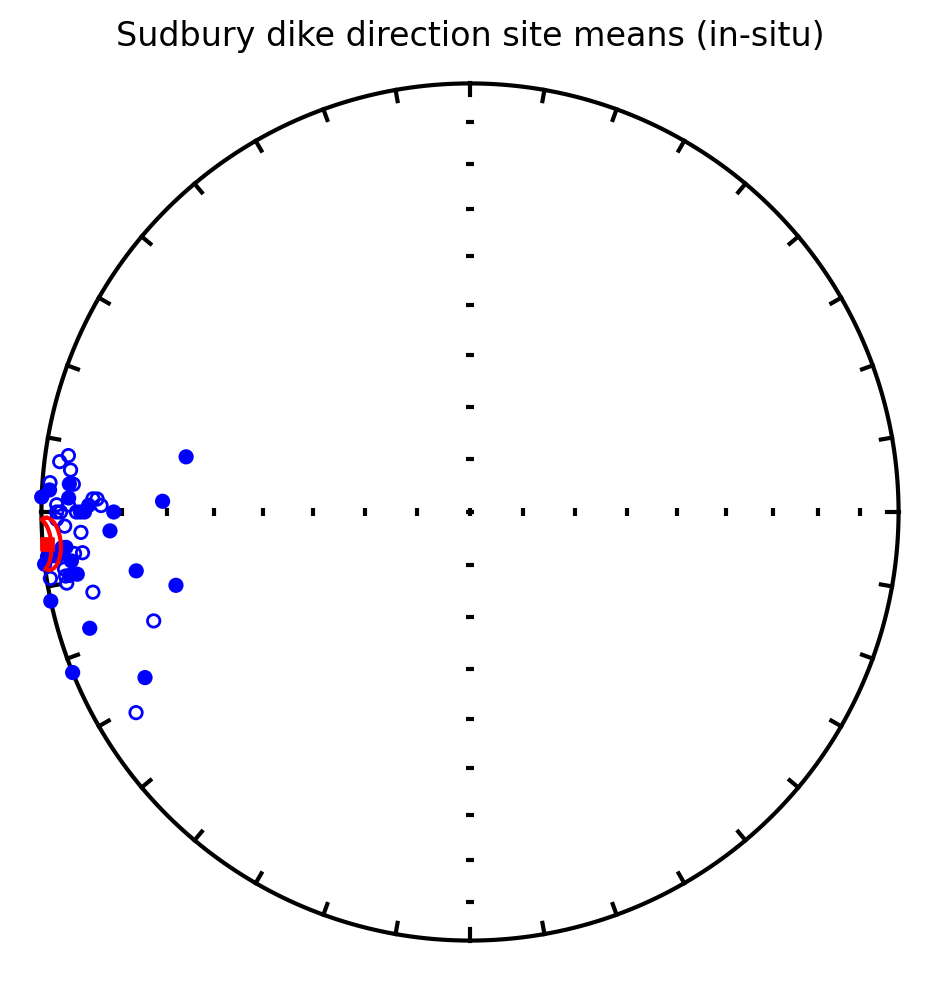

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sudbury, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.title('Sudbury dike direction site means (in-situ)')
plt.show()

## Field test: baked contacts and the Grenville-Front overprint

Palmer et al. (1977) demonstrated the primary origin of the Sudbury dike
magnetization with a positive baked-contact test at site 90, where a dike with
the Sudbury dike direction bakes Gowganda Formation argillites whose
characteristic remanence is steeply down (the regional Grenville remanence),
together with the earlier positive baked-contact tests of Sopher (1963) and
Schwarz (1977) against Sudbury norite. Approaching the Grenville Front, the dikes
are remagnetized to the east-southeast-and-down Grenville Front direction. The
two directional populations are plotted below.

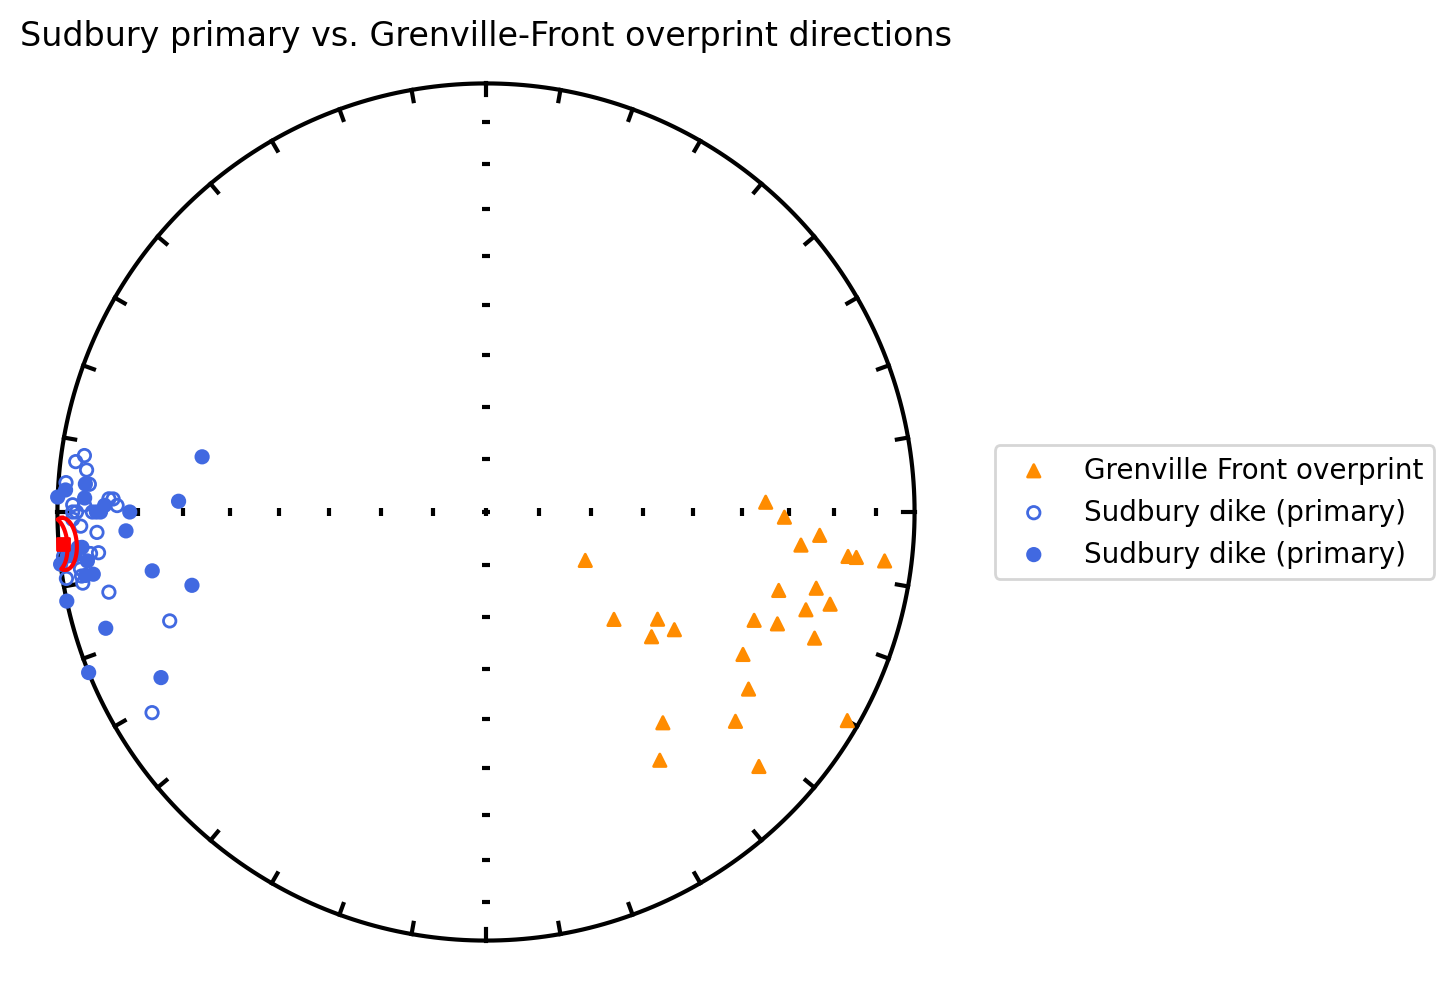

In [5]:
ipmag.plot_net()
ipmag.plot_di(grenville['dir_dec'].tolist(), grenville['dir_inc'].tolist(),
              color='darkorange', marker='^', label='Grenville Front overprint')
ipmag.plot_di(sudbury['dir_dec'].tolist(), sudbury['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Sudbury dike (primary)')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Sudbury primary vs. Grenville-Front overprint directions')
plt.show()

## R2: Deenen test

The Deenen et al. (2011) envelope is evaluated separately from the VGP-shape
tests so that each diagnostic figure renders in its own notebook output.

A_95 of 2.5 passes Deenen et al. (2011) criteria of being between 2.5 and 6.8 for this number of sites


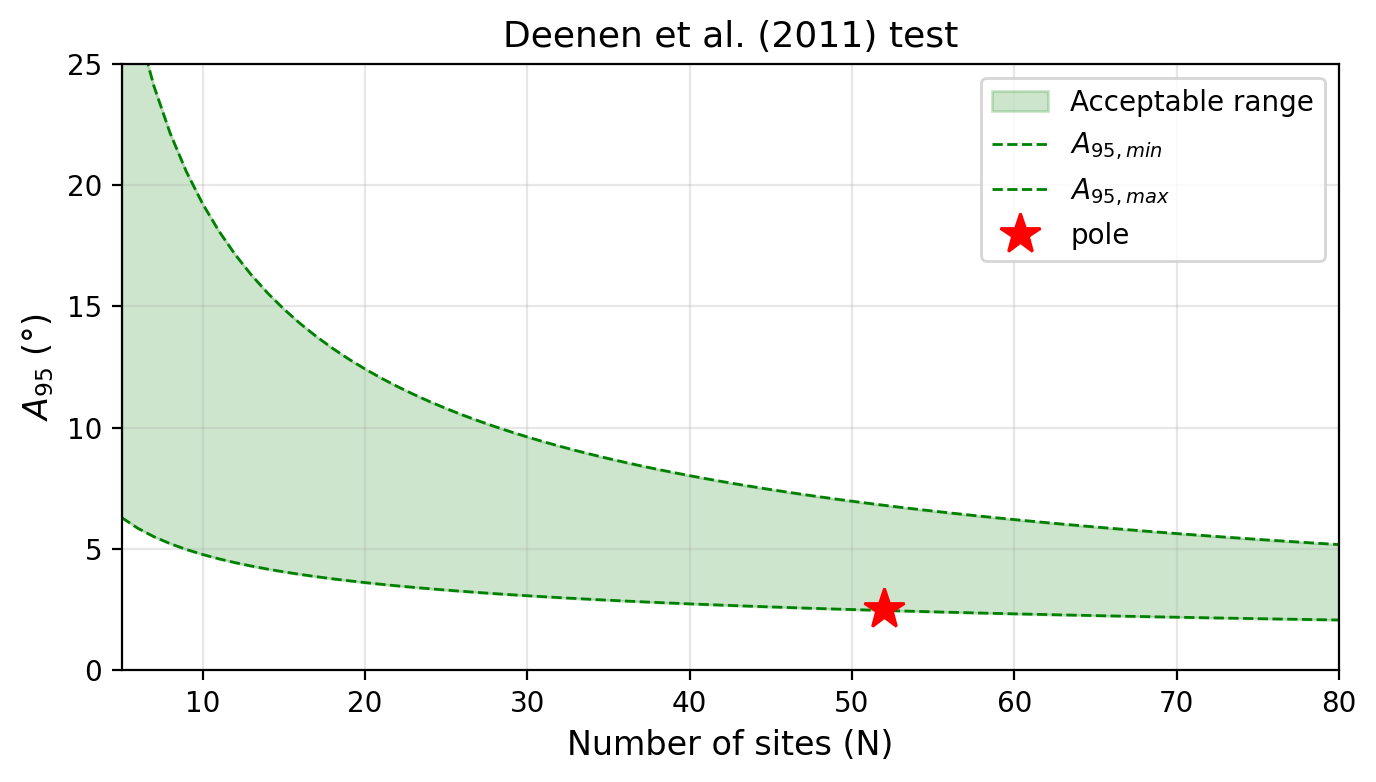

In [6]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()
plt.close('all')

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site/dyke VGPs are drawn
from a Fisher distribution, and the shape-elongation/inclination (SVEI) test
compares the VGP-scatter elongation against the TK03.GAD paleosecular-variation
model expectation at the sampling paleolatitude.

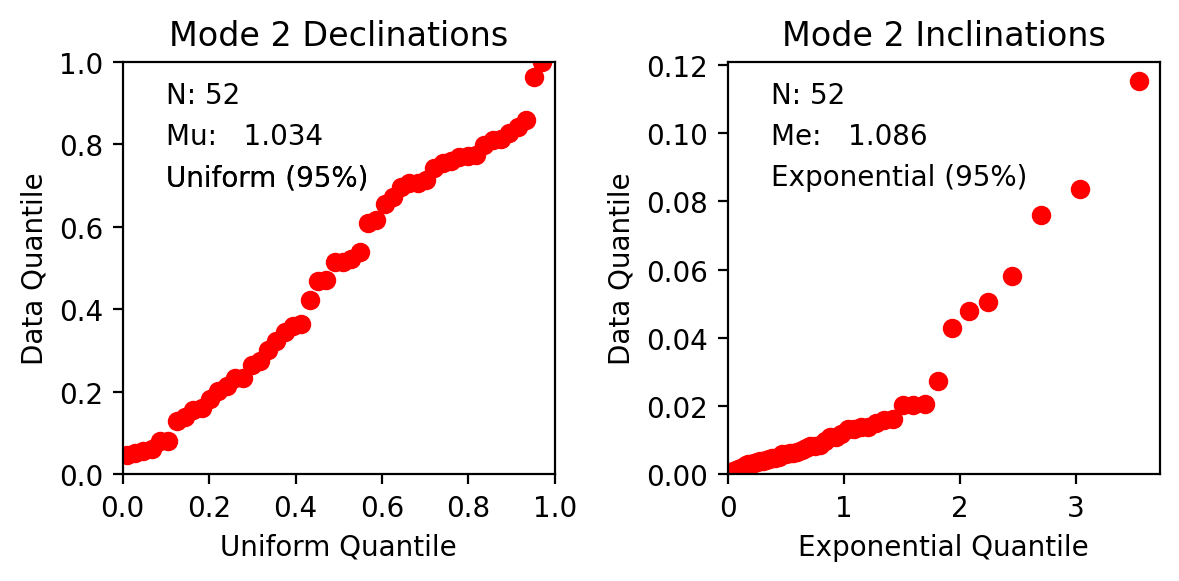

({},
 {'Mode': 'Mode 2',
  'Dec': -167.77235147205772,
  'Inc': -2.4266599261891253,
  'N': 52,
  'Mu': 1.0342272731782591,
  'Mu_critical': 1.207,
  'Me': 1.0857972734859682,
  'Me_critical': 1.094,
  'Test_result': 'Consistent with Fisher distribution'})

In [7]:
fishqq_result = pt.fishqq_vgps(sudbury, unify_polarity=False)
plt.show()
plt.close('all')
fishqq_result

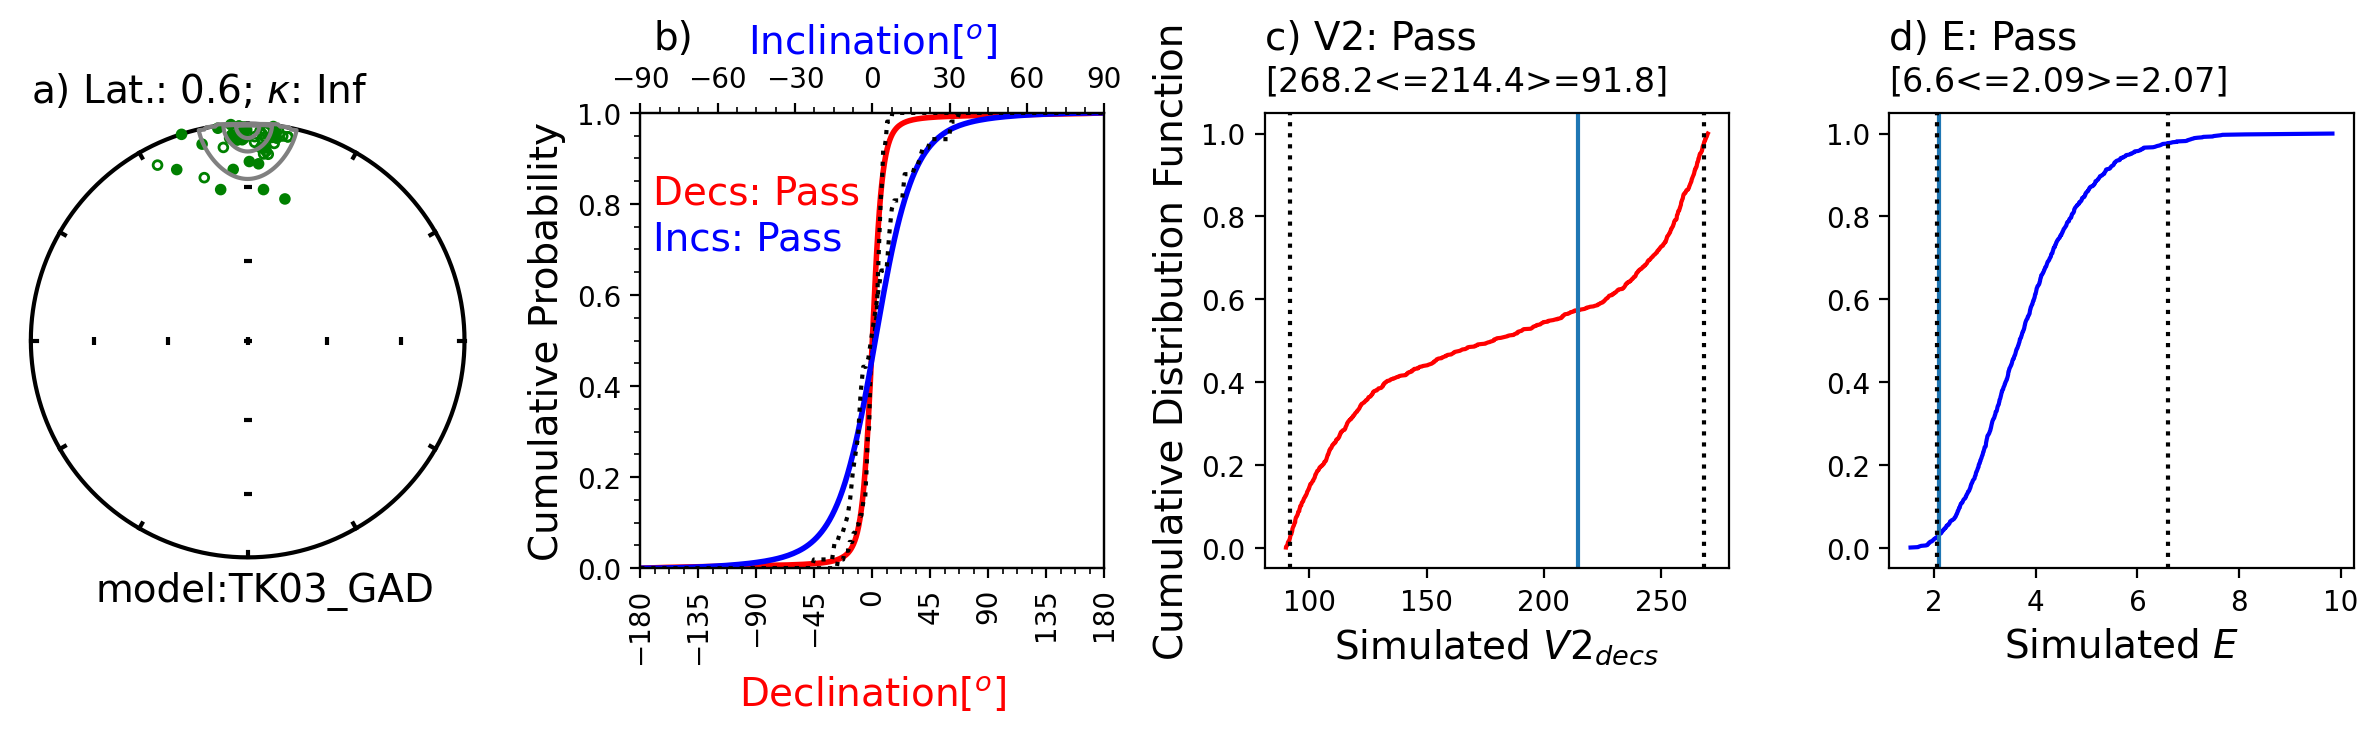

paleolatitude = 0.6 deg; elongation E = 2.09 (consistent with TK03.GAD)


In [8]:
try:
    svei_result = pt.svei_test_vgps(sudbury, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:   # PmagPy plotting bug when elongation falls below the model minimum
    svei_result = pt.svei_test_vgps(sudbury, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")
plt.show()
plt.close('all')

## The Sudbury pole in the context of the Laurentia APWP

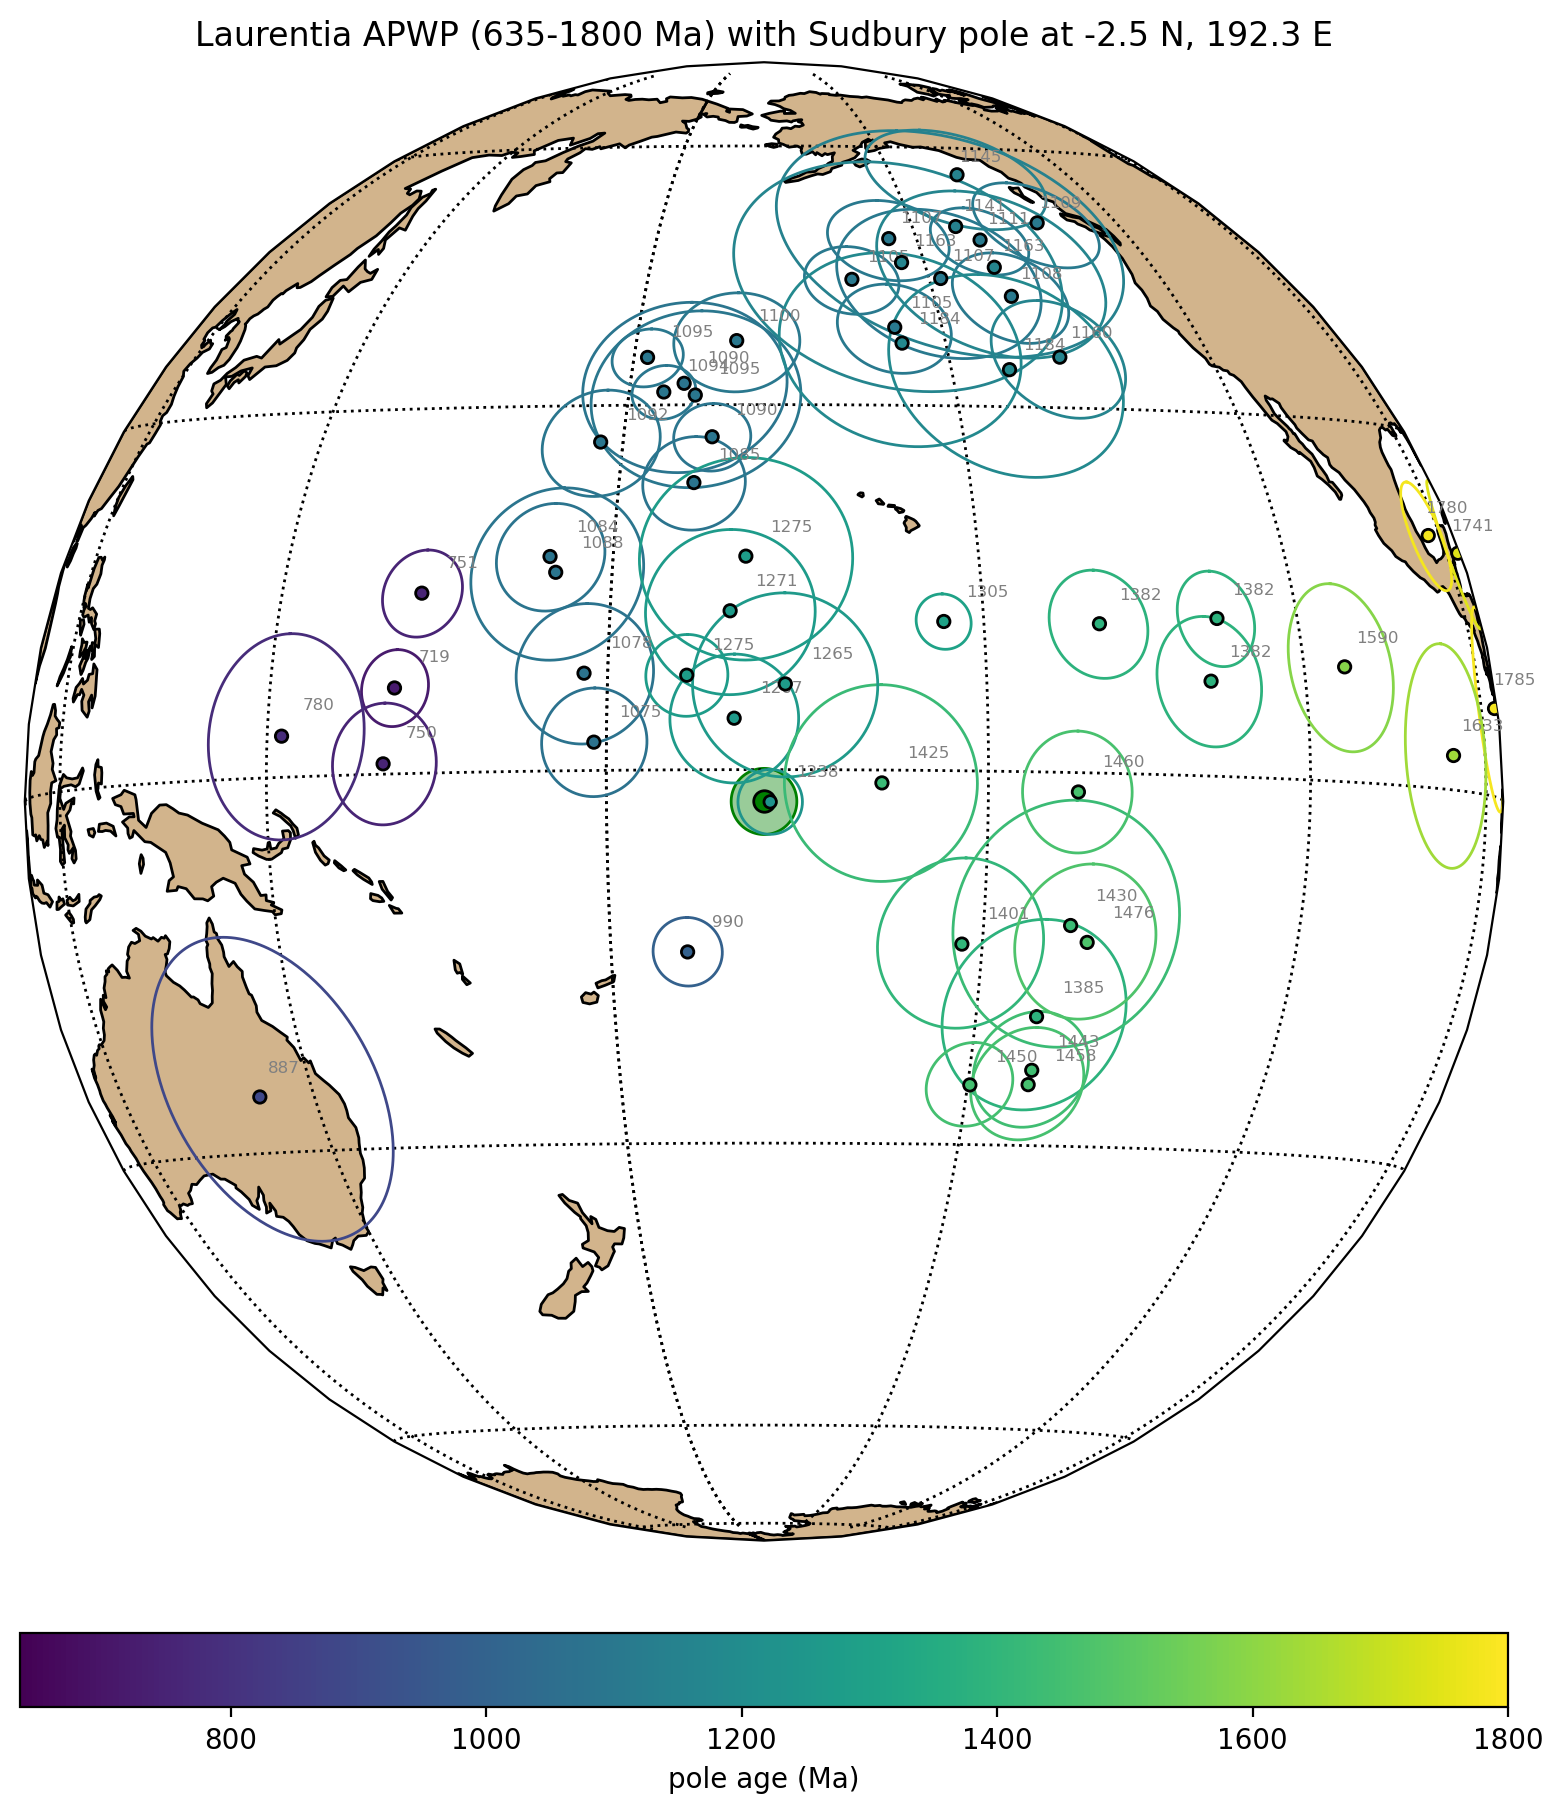

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
age_min, age_max = 635, 1800
excluded_terranes = ('Laurentia-Scotland', 'Laurentia-Svalbard')
path_poles = Laurentia_poles[
    (Laurentia_poles['nominal age'] >= age_min) &
    (Laurentia_poles['nominal age'] <= age_max) &
    (Laurentia_poles['PLAT_rotated'].notna()) &
    (~Laurentia_poles['Terrane'].isin(excluded_terranes))
]

ax = ipmag.make_orthographic_map(central_longitude=pole_mean['dec'],
                                 central_latitude=pole_mean['inc'],
                                 figsize=(12, 12))
ipmag.plot_poles_colorbar(ax,
                          path_poles['PLONG_rotated'].tolist(),
                          path_poles['PLAT_rotated'].tolist(),
                          path_poles['A95'].tolist(),
                          path_poles['nominal age'].tolist(),
                          age_min, age_max,
                          colormap='viridis')

for _, row in path_poles.iterrows():
    ax.text(row['PLONG_rotated'] + 2, row['PLAT_rotated'] + 2,
            str(int(row['nominal age'])),
            transform=pt.ccrs.PlateCarree(), fontsize=6, color='gray')

ipmag.plot_pole(ax, pole_mean['dec'], pole_mean['inc'], pole_mean['alpha95'],
                color='green', markersize=60, filled_pole=True,
                fill_color='green', fill_alpha=0.4)
ax.set_title(f"Laurentia APWP ({age_min}-{age_max} Ma) with Sudbury pole at "
             f"{pole_mean['inc']:.1f} N, {pole_mean['dec']:.1f} E")
plt.show()
plt.close('all')

## R7: comparison with younger Laurentia poles

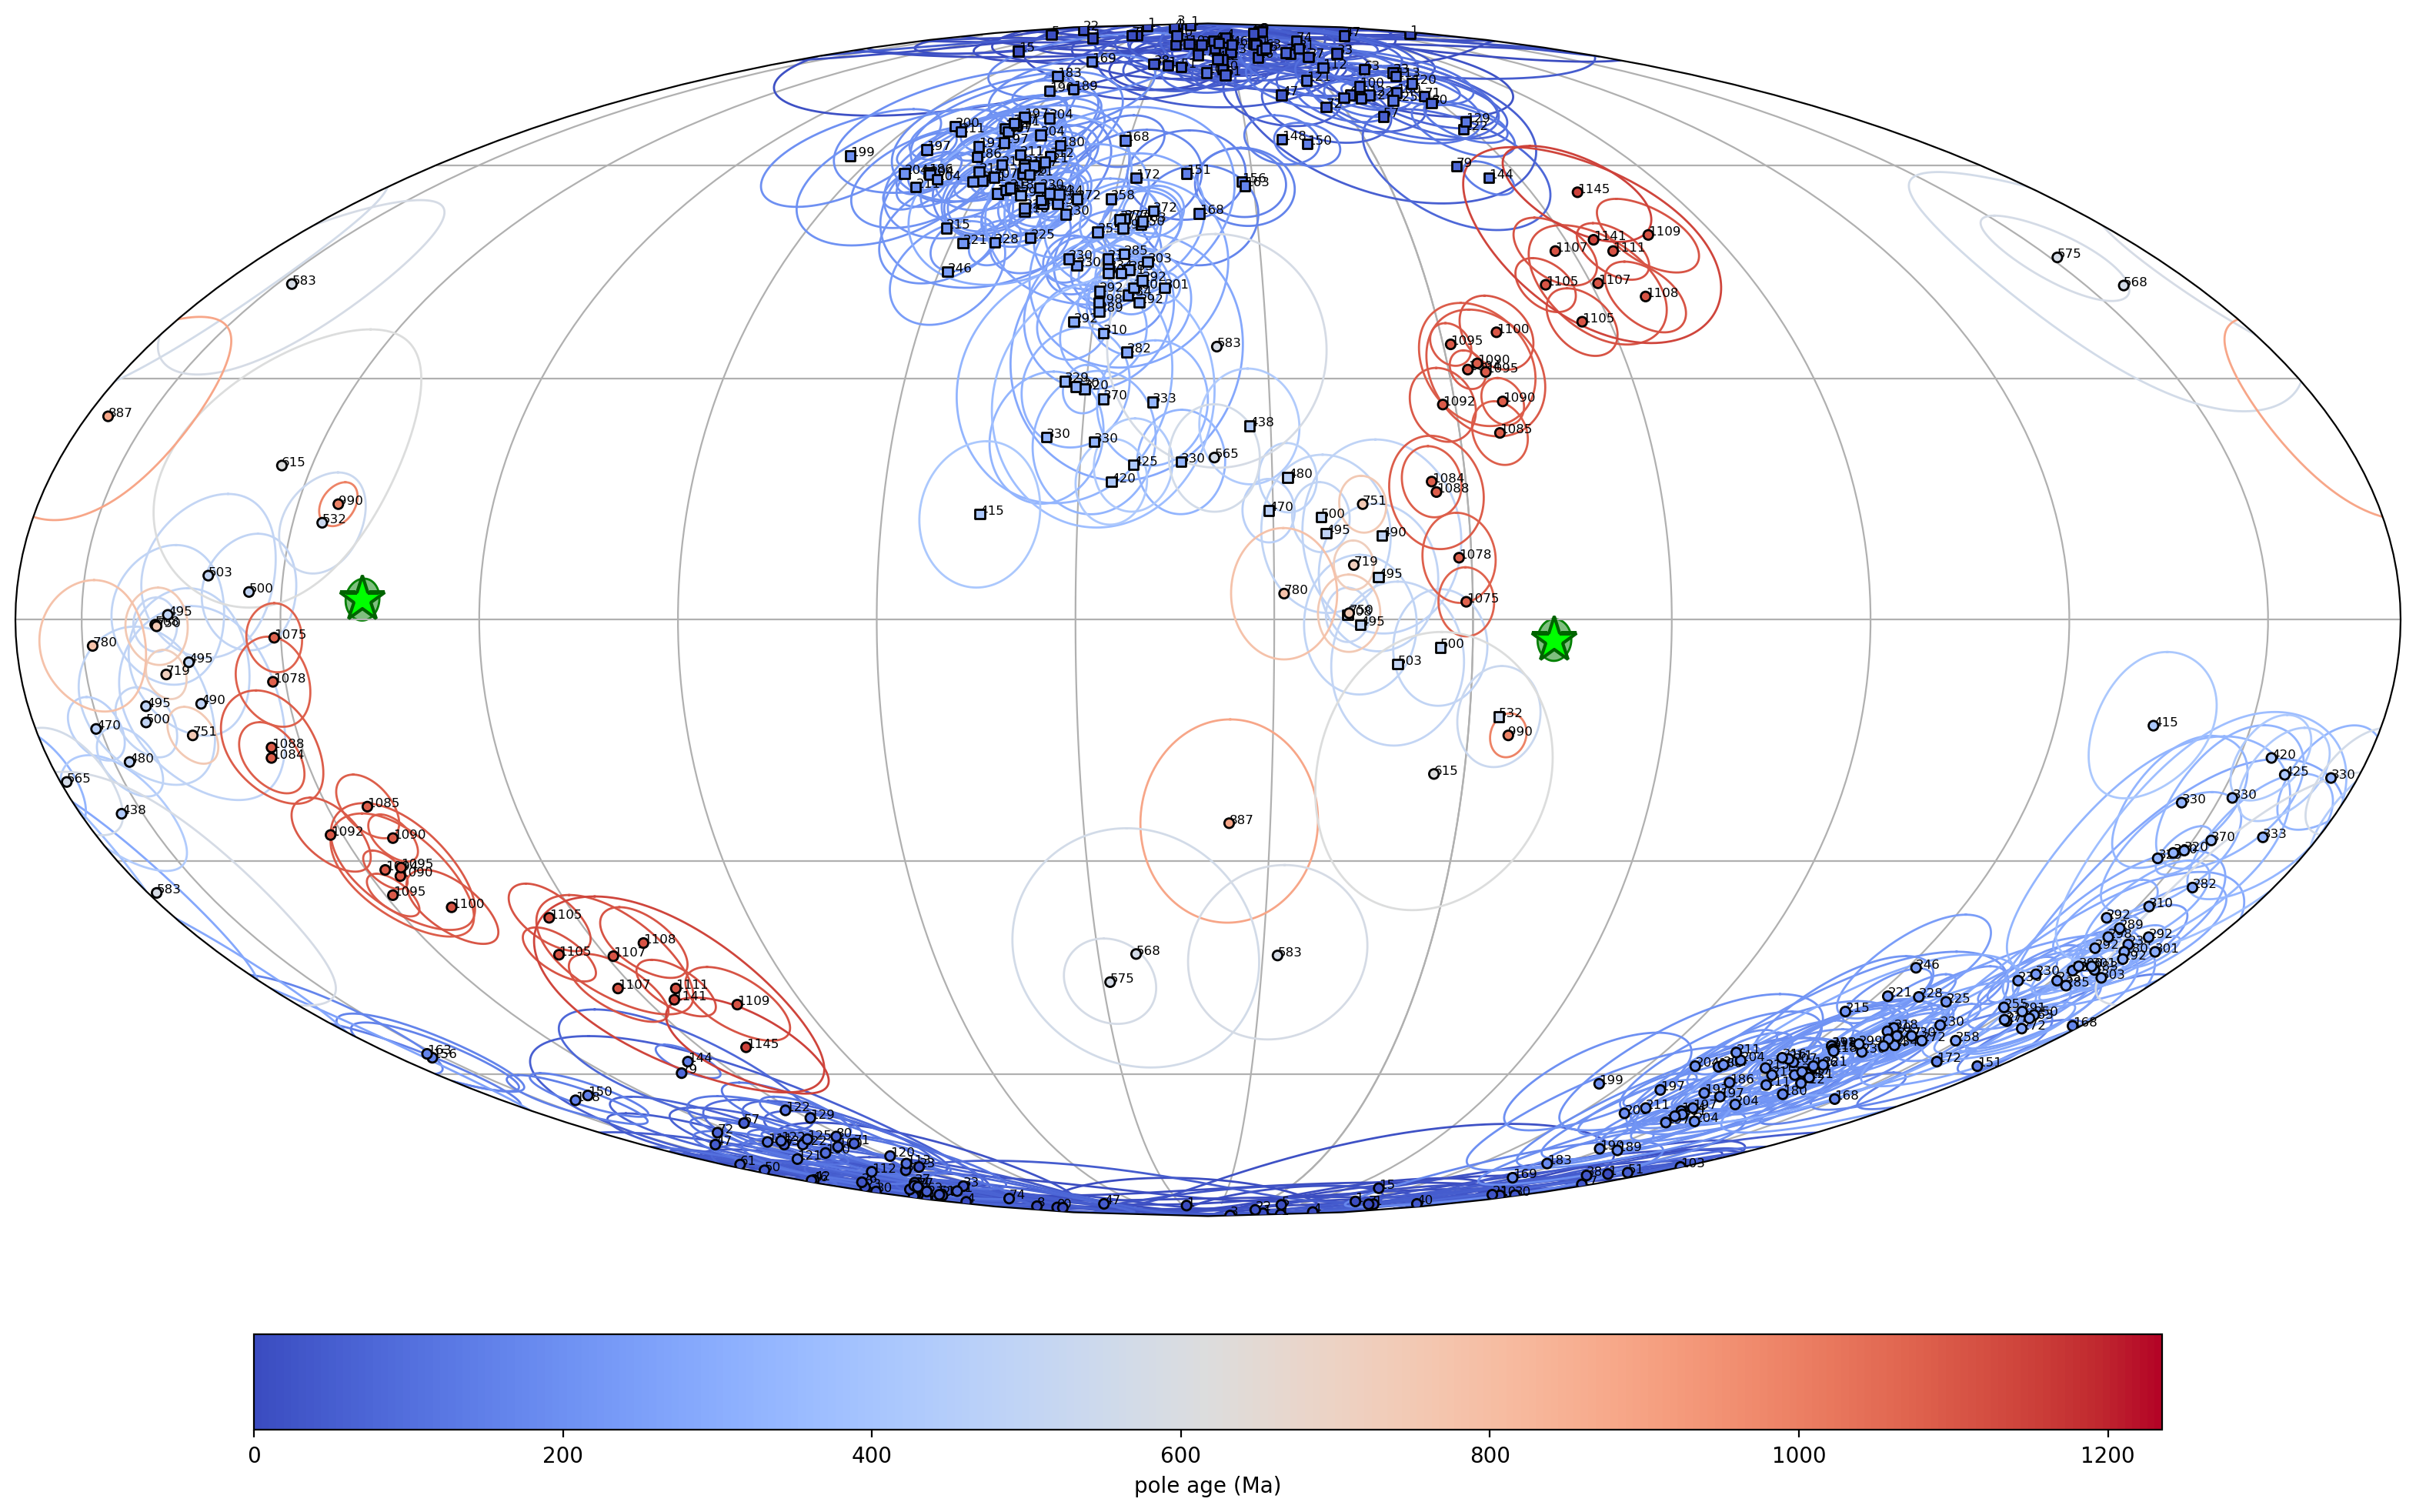

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Sudbury Dike Swarm', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1235)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1235 +7/-3 Ma on the Sudbury swarm (Dudas et al., 1994); compatible with the earlier 1238 ± 4 Ma constraint (Krogh et al., 1987; Fahrig & West, 1986). |
| 2 | Techniques and statistical analysis | **1** | AF (and thermal) demagnetization with stable-endpoint analysis; B = 52 site/dyke VGPs and N = 205 samples/cores, K = 61.1, A95 = 2.5° passes the Deenen et al. (2011) envelope. This updates the prior compilation R2 = 0, which reflected the artificially high K = 1000 of the combined-result entry. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite in the olivine diabase, with rock-magnetic (Curie point) characterization (Palmer et al., 1977); Larochelle (1967) and Stupavsky & Symons (1982) report stable magnetite-carried Sudbury dike directions. |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test at site 90 against Gowganda argillites, plus the positive baked-contact tests of Sopher (1963) and Schwarz (1977) against Sudbury norite, establish a primary magnetization. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Southern Province of the Canadian Shield; vertical dikes require no tilt correction. |
| 6 | Presence of reversals | **0** | The primary Sudbury dike direction is of single polarity. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles; the ESE-down Grenville-Front overprint (ca. 1000 Ma) is a separate, identified population. |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The primary Sudbury Dike Swarm pole is recreated at the site/dyke level from 52
Sudbury-dike-direction means: 38 Palmer et al. (1977) sites, 11 Larochelle
(1967) dyke means, and three Stupavsky & Symons (1982) sites. The recompiled
dataset has B = 52 and N = 205, matching Evans et al. (2021). Its Fisher mean
from the rounded tabulated VGPs is -2.5°N/192.3°E, A95 2.5°, within 0.5° of
the Evans et al. (2021) longitude (-2.5°N/192.8°E, A95 2.5°). R2 is scored
directly from the recreated VGPs (K = 61.1, A95 passes Deenen), rather than from
the over-concentrated K = 1000 recorded in the prior combined entry.

In [11]:
sudbury_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Sudbury Dike Swarm',
    sites=sudbury,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary Sudbury dike direction (westerly, shallow); magnetite-carried characteristic remanent magnetization',
    tests='C+ (positive baked-contact test at site 90 vs. Gowganda argillites; Sopher, 1963; Schwarz, 1977 vs. Sudbury norite)',
    gpmdb_number='2175',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=0, R7=1, Grade='A', Grade_E21='A',
    nominal_age=1235, lomagage=1232, himagage=1242,
    REF_method='U-Pb baddeleyite age 1235 +7/-3 Ma on the Sudbury dike swarm (Dudas et al., 1994), compatible with Krogh et al. (1987) and Fahrig & West (1986), superseding the ca. 1250 Ma K-Ar estimate of Palmer et al. (1977).',
    POLE_AUTHORS='Palmer, H. C., Merz, B. A., Hayatsu, A.; Larochelle, A.; Stupavsky, M., & Symons, D. T. A.',
    YEAR=1977,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='14',
    VPAGES='1867-1887',
    TITLE='The Sudbury dikes of the Grenville Front region: paleomagnetism, petrochemistry, and K-Ar age studies',
    COMMENT='Primary Sudbury Dike Swarm pole recreated at the site/dyke level from 52 Sudbury-dike-direction means: 38 Palmer et al. (1977) sites (audited MagIC contribution 20644), 11 Larochelle (1967) dyke means from Table II, and three Stupavsky & Symons (1982) Sudbury-like sites. Recreated from rounded tabulated VGPs as -2.5N/192.3E, A95 2.5, B=52, N=205; B/N exactly match Evans et al. (2021), and the pole is within 0.5 deg longitude of the prior compilation combined pole (-2.5N/192.8E, GPMDB 2175, A95 2.5, B=52, N=205). Schwarz & Buchan (1982) supports contact/uplift context and does not tabulate independent dike site means for this pole. Positive baked-contact test (site 90; Sopher 1963; Schwarz 1977). R2 updated 0->1 (recreated VGP K=61.1 passes Deenen; prior 0 reflected the combined-entry K=1000). Single primary polarity (R6=0). Grenville-Front ESE-down overprint (ca. 1000 Ma) shown for context.'
)
pt.save_nordic_summary(sudbury_summary, '1235_Sudbury')
sudbury_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Sudbury Dike Swarm,GPMDB:2175,"Primary Sudbury dike direction (westerly, shal...",C+ (positive baked-contact test at site 90 vs....,0,46.3,278.6,52,205,...,1242,U-Pb baddeleyite age 1235 +7/-3 Ma on the Sudb...,Sudbury Dike Swarm,"Palmer, H. C., Merz, B. A., Hayatsu, A.; Laroc...",1977,Canadian Journal of Earth Sciences,14,1867-1887,The Sudbury dikes of the Grenville Front regio...,Primary Sudbury Dike Swarm pole recreated at t...
